# Firasa (LSTM version): LSTM (Branch 2) + Final Models Comparison

The original Firasa proposal specified an **LSTM** for Branch 2. An earlier validation-only
tuning experiment compared architectures and switched Branch 2 to a **GRU** after it won by
a small, consistent margin. That experiment compared architectures on validation only: it
never actually finished training, saving, and testing the LSTM end-to-end the way the GRU
was.

This notebook builds the **LSTM** branch properly, fuses it with **Branch 1 (XGBoost)**
using the same fusion recipe throughout, and at the end puts every model built across the
whole project, baseline through both Fusion variants, side by side in one table.

| Component | Where it lives | Input |
|---|---|---|
| **Branch 1, XGBoost** | Trained separately (not retrained here); its scores are loaded from `branch1_scores.csv` | Aggregated customer features |
| **Branch 2, LSTM** | Trained in this notebook (the original proposal's architecture) | Padded 13-month sequences |
| **Fusion and Decision Layer** | Trained in this notebook: combines both branches into one risk score, mapped to 4 risk levels with a recommended action | Probability outputs from Branch 1 and 2 |

### Checkpoints: measuring the 3 to 6-month early detection window
Both branches score every customer at three points in their history, so results are directly
comparable across checkpoints.

| Checkpoint | History the models may use | Business question |
|---|---|---|
| **6 months before** the last statement | Statements up to that point | Could we have warned 6 months early? |
| **3 months before** the last statement | Statements up to that point | Could we have warned 3 months early? |
| **Last statement** | Full history | Current risk, the same setting as the Phase 2 baseline |

In the AmEx data, `target = 1` means the customer defaulted (missed 4+ payments) within
120 days of their last statement.

**Note:** this notebook builds and evaluates the LSTM branch end-to-end (Parts A to D). The final, side-by-side comparison of every model built for this project, including the LSTM vs. GRU adoption decision, is in Part E: Final Comparison, at the very end of this notebook. If you're only here for the bottom-line numbers, jump straight there.


## Step 1: Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os, json, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                             precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', 50)

# ---------------- Configuration ----------------
DATA_DIR     = '/content/data'
TRAIN_FILE   = f'{DATA_DIR}/amex_train.parquet'   # row-level (monthly) files from EDA Step 18
TEST_FILE    = f'{DATA_DIR}/amex_test.parquet'
ARTIFACT_DIR = '/content/data/firasa_artifacts'   # shared with the XGBoost notebook (Step 10)
BRANCH1_FILE = f'{ARTIFACT_DIR}/branch1_scores.csv'

CHECKPOINTS = [6, 3, 0]   # months before the last statement
CHECKPOINT_NAMES = {6: '6 months before', 3: '3 months before', 0: 'Last statement'}

BRANCH2_EPOCHS = 100
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

firasa_CMAP = LinearSegmentedColormap.from_list('firasaCmap', ['white', 'steelblue', '#DAA520'])
MODEL_COLORS = {'XGBoost (Branch 1)': 'steelblue', 'LSTM (Branch 2)': '#8FBF9F', 'Fusion': '#DAA520'}

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


# Part A - Build and tune everything on train / validation
## Step 2: Load the monthly data and the Branch 1 scores

In [3]:
train_df = pd.read_parquet(TRAIN_FILE)
test_df  = pd.read_parquet(TEST_FILE)
train_df = train_df.sort_values(['customer_ID', 'S_2']).reset_index(drop=True)
test_df  = test_df.sort_values(['customer_ID', 'S_2']).reset_index(drop=True)
assert not (set(train_df['customer_ID']) & set(test_df['customer_ID'])), "Customer leakage between train and test!"

branch1 = pd.read_csv(BRANCH1_FILE)

print("Row-level train:", train_df.shape, "| customers:", train_df['customer_ID'].nunique())
print("Row-level test: ", test_df.shape,  "| customers:", test_df['customer_ID'].nunique())
print("\nBranch 1 scores (customers per checkpoint):")
print(branch1.groupby(['split', 'months_before_last'])['customer_ID'].nunique().unstack())

Row-level train: (401237, 367) | customers: 33185
Row-level test:  (99795, 367) | customers: 8297

Branch 1 scores (customers per checkpoint):
months_before_last     0     3     6
split                               
test                8297  7980  7695
validation          6637  6424  6230


## Step 3: Branch 2 input columns and categorical encoding

- `n_statements` (from the EDA) is a customer's **total** number of statements. At an early
  checkpoint it reveals how much history is still to come, so Branch 2 does not use it
  (sequence length already tells the model how much history it has seen).
- `D_63` / `D_64` are ordinal-encoded with categories learned from train only.
- This keeps Branch 2's inputs clean and leakage-free, so any performance characteristic
  observed later comes from the recurrent architecture itself, not from the preprocessing.


In [4]:
ID_COLS    = ['customer_ID', 'S_2', 'target', 'year', 'month']
CAT_COLS   = [c for c in ['D_63', 'D_64'] if c in train_df.columns]
LEAKY_COLS = [c for c in ['n_statements'] if c in train_df.columns]
SEQ_COLS  = [c for c in train_df.columns if c not in ID_COLS + LEAKY_COLS + CAT_COLS] + CAT_COLS

ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train_df[CAT_COLS] = ord_enc.fit_transform(train_df[CAT_COLS].astype(str))
test_df[CAT_COLS]  = ord_enc.transform(test_df[CAT_COLS].astype(str))

train_df[SEQ_COLS] = train_df[SEQ_COLS].astype('float32')
test_df[SEQ_COLS]  = test_df[SEQ_COLS].astype('float32')

print(f"Branch 2 uses {len(SEQ_COLS)} columns per month | dropped as leaky: {LEAKY_COLS}")

Branch 2 uses 361 columns per month | dropped as leaky: ['n_statements']


## Step 4: Use the same validation customers as Branch 1

The fusion layer is fitted on validation customers, so both branches must hold out exactly the
same people. The validation IDs are taken straight from `branch1_scores.csv`; every other
train customer is used to train Branch 2.

In [5]:
val_ids = np.sort(branch1.loc[branch1['split'] == 'validation', 'customer_ID'].unique())
all_train_ids = np.sort(train_df['customer_ID'].unique())
tr_ids = np.setdiff1d(all_train_ids, val_ids)

assert set(val_ids) <= set(all_train_ids), "Branch 1 validation customers are not in amex_train: check the file paths."
assert set(branch1.loc[branch1['split'] == 'test', 'customer_ID']) == set(test_df['customer_ID']), \
    "Branch 1 test customers do not match amex_test: check the file paths."

cust_target = train_df.groupby('customer_ID')['target'].first()
print(f"Branch 2 train customers: {len(tr_ids)} (default rate {cust_target.loc[tr_ids].mean():.3f})")
print(f"Validation customers: {len(val_ids)} (default rate {cust_target.loc[val_ids].mean():.3f})")

Branch 2 train customers: 26548 (default rate 0.253)
Validation customers: 6637 (default rate 0.253)


## Step 5: Padded 13-month sequences

The scaler is fitted on **Branch 2 train customers only**. Sequences are padded at the *front*, so
the last real statement always sits in the last array position, and "h months before the last
statement" is always position `MAX_LEN - 1 - h`.

In [6]:
scaler = StandardScaler()
scaler.fit(train_df.loc[train_df['customer_ID'].isin(tr_ids), SEQ_COLS])
train_df[SEQ_COLS] = scaler.transform(train_df[SEQ_COLS]).astype('float32')
test_df[SEQ_COLS]  = scaler.transform(test_df[SEQ_COLS]).astype('float32')

MAX_LEN = int(train_df.groupby('customer_ID').size().max())

def build_sequences(df):
    seqs, ids, labels, lengths = [], [], [], []
    for cid, g in df.groupby('customer_ID', sort=True):
        seqs.append(g[SEQ_COLS].to_numpy(dtype='float32'))
        ids.append(cid)
        labels.append(int(g['target'].iloc[0]))
        lengths.append(len(g))
    X = keras.preprocessing.sequence.pad_sequences(
        seqs, maxlen=MAX_LEN, dtype='float32', padding='pre', truncating='pre', value=0.0)
    return X, np.array(ids, dtype=object), np.array(labels), np.array(lengths)

X_all, ids_all, y_all, len_all = build_sequences(train_df)
X_test_seq, ids_test, y_test, len_test = build_sequences(test_df)

tr_mask  = np.isin(ids_all, tr_ids)
val_mask = np.isin(ids_all, val_ids)
X_tr,  y_tr,  len_tr,  ids_tr  = X_all[tr_mask],  y_all[tr_mask],  len_all[tr_mask],  ids_all[tr_mask]
X_val, y_val, len_val, ids_val = X_all[val_mask], y_all[val_mask], len_all[val_mask], ids_all[val_mask]
del X_all; gc.collect()

print(f"MAX_LEN = {MAX_LEN} | features per month = {X_tr.shape[2]}")
print("Train:", X_tr.shape, "| Validation:", X_val.shape, "| Test:", X_test_seq.shape)

MAX_LEN = 13 | features per month = 361
Train: (26548, 13, 361) | Validation: (6637, 13, 361) | Test: (8297, 13, 361)


## Step 6: Train Branch 2 (many-to-many LSTM)

- Both LSTM layers return sequences and a `TimeDistributed` head outputs **one risk score per
  month**. Because the LSTM only reads forward, the score at month *t* uses statements up to
  month *t* only, so it is a valid early-warning score at any checkpoint.
- The customer's single label is repeated across their real months. A per-month
  `sample_weight` gives padded months weight 0 and multiplies defaulters' months by
  `scale_pos_weight` (the same class balancing used in every earlier model).
- Early stopping monitors the **mean validation ROC-AUC across the 3 checkpoints**, the metric
  Firasa actually cares about, computed on real (non-padded) months only.
- **Architecture:** 64 to 32 stacked LSTM units, dropout 0.3, learning rate 1e-3, sized so
  that any accuracy difference against a GRU-based Branch 2 traces to the recurrent cell
  itself (3-gate LSTM vs. 2-gate GRU), not to unequal capacity.
- **cuDNN fix:** `use_cudnn=False` is set explicitly. cuDNN's fast GPU path for LSTM/GRU only
  supports a narrow set of layer configurations (specific activation, no masking edge cases);
  a `Masking` layer upstream of these layers, combined with `sample_weight`, can fall outside
  it and throw a cuDNN error on some Colab GPU runtimes. Forcing the plain (non-cuDNN)
  implementation trades a little training speed for a build that always runs, regardless of
  the GPU behind it.


In [7]:
def branch2_checkpoint_scores(pred_full, ids, lengths, y):
    frames = []
    for h in CHECKPOINTS:
        ok = lengths > h
        frames.append(pd.DataFrame({
            'customer_ID': ids[ok], 'months_before_last': h, 'target': y[ok],
            'p_branch2': pred_full[ok, MAX_LEN - 1 - h],
        }))
    return pd.concat(frames, ignore_index=True)

def per_month_weights(lengths, y, pos_weight):
    w = np.zeros((len(lengths), MAX_LEN), dtype='float32')
    for i, L in enumerate(lengths):
        w[i, MAX_LEN - L:] = pos_weight if y[i] == 1 else 1.0
    return w

pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
Y_tr_seq  = np.repeat(y_tr[:, None], MAX_LEN, axis=1)[..., None].astype('float32')
W_tr_seq  = per_month_weights(len_tr, y_tr, pos_weight)

class CheckpointAUC(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        pred = self.model.predict(X_val, batch_size=1024, verbose=0)[:, :, 0]
        s = branch2_checkpoint_scores(pred, ids_val, len_val, y_val)
        aucs = {h: roc_auc_score(g['target'], g['p_branch2']) for h, g in s.groupby('months_before_last')}
        logs['val_checkpoint_auc'] = float(np.mean(list(aucs.values())))
        print(f"  val AUC - 6m before: {aucs[6]:.4f} | 3m before: {aucs[3]:.4f} | last: {aucs[0]:.4f} "
              f"| mean: {logs['val_checkpoint_auc']:.4f}")

n_features = X_tr.shape[2]
branch2_model = keras.Sequential([
    layers.Input(shape=(MAX_LEN, n_features)),
    layers.Masking(mask_value=0.0),
    layers.LSTM(64, return_sequences=True, use_cudnn=False),
    layers.Dropout(0.3),
    layers.LSTM(32, return_sequences=True, use_cudnn=False),
    layers.Dropout(0.3),
    layers.TimeDistributed(layers.Dense(16, activation='relu')),
    layers.TimeDistributed(layers.Dense(1, activation='sigmoid')),
])
branch2_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
branch2_model.summary()

history = branch2_model.fit(
    X_tr, Y_tr_seq, sample_weight=W_tr_seq,
    epochs=BRANCH2_EPOCHS, batch_size=256, verbose=2,
    callbacks=[
        CheckpointAUC(),
        keras.callbacks.ReduceLROnPlateau(monitor='val_checkpoint_auc', mode='max', factor=0.5, patience=3, min_lr=1e-5, verbose=1),
        keras.callbacks.EarlyStopping(monitor='val_checkpoint_auc', mode='max', patience=6, restore_best_weights=True, verbose=1),
    ],
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 13, 361)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 13, 64)         │       109,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 13, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 13, 16)         │           528 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 13, 1)          │            17 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,017 (476.63 KB)

 Trainable params: 122,017 (476.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
  val AUC - 6m before: 0.9249 | 3m before: 0.9371 | last: 0.9497 | mean: 0.9373
104/104 - 11s - 101ms/step - loss: 0.5935 - val_checkpoint_auc: 0.9373 - learning_rate: 0.0010
Epoch 2/100
  val AUC - 6m before: 0.9285 | 3m before: 0.9409 | last: 0.9536 | mean: 0.9410
104/104 - 9s - 88ms/step - loss: 0.4931 - val_checkpoint_auc: 0.9410 - learning_rate: 0.0010
Epoch 3/100
  val AUC - 6m before: 0.9293 | 3m before: 0.9415 | last: 0.9539 | mean: 0.9415
104/104 - 7s - 66ms/step - loss: 0.4693 - val_checkpoint_auc: 0.9415 - learning_rate: 0.0010
Epoch 4/100
  val AUC - 6m before: 0.9292 | 3m before: 0.9411 | last: 0.9535 | mean: 0.9413
104/104 - 10s - 96ms/step - loss: 0.4488 - val_checkpoint_auc: 0.9413 - learning_rate: 0.0010
Epoch 5/100
  val AUC - 6m before: 0.9273 | 3m before: 0.9390 | last: 0.9516 | mean: 0.9393
104/104 - 6s - 54ms/step - loss: 0.4327 - val_checkpoint_auc: 0.9393 - learning_rate: 0.0010
Epoch 6/100
  val AUC - 6m before: 0.9241 | 3m before: 0.9354 | last: 0.

Branch 2 validation ROC-AUC - 6 months before : 0.9293  (n=6230)
Branch 2 validation ROC-AUC - 3 months before : 0.9415  (n=6424)
Branch 2 validation ROC-AUC - Last statement  : 0.9539  (n=6637)


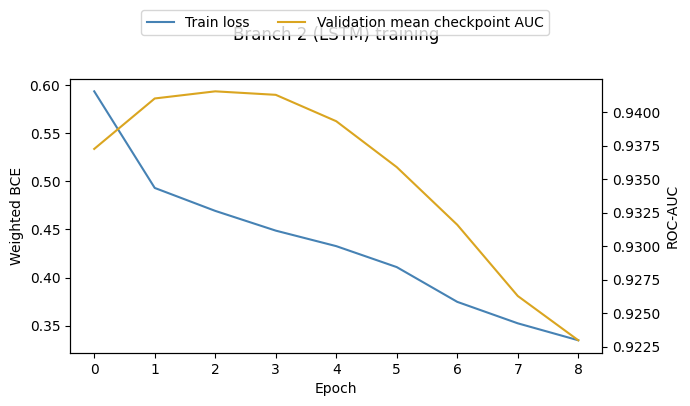

In [31]:
b2_val_scores = branch2_checkpoint_scores(
    branch2_model.predict(X_val, batch_size=1024, verbose=0)[:, :, 0], ids_val, len_val, y_val)

for h in CHECKPOINTS:
    s = b2_val_scores[b2_val_scores['months_before_last'] == h]
    print(f"Branch 2 validation ROC-AUC - {CHECKPOINT_NAMES[h]:<16}: {roc_auc_score(s['target'], s['p_branch2']):.4f}  (n={len(s)})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history.history['loss'], color='steelblue', label='Train loss')
ax2 = ax.twinx()
ax2.plot(history.history['val_checkpoint_auc'], color='#DAA520', label='Validation mean checkpoint AUC')
ax.set_xlabel('Epoch'); ax.set_ylabel('Weighted BCE'); ax2.set_ylabel('ROC-AUC')
fig.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.title('Branch 2 (LSTM) training', pad=28)
plt.tight_layout(); plt.show()

## Step 6b: Simple Ensemble First (Naive Average, Before the Learned Fusion Layer)

Before reaching for a trained meta-model, it's worth trying the cheapest possible combination
first: just average the two probabilities, 50/50, no training required. If this crude average
already matches the fancier logistic-regression Fusion layer below, the fancier layer isn't
earning its own complexity.

When two models share highly correlated errors (for example, when they're trained on the
exact same feature set), naive averaging typically lands *between* the two rather than
beating both, there's no genuinely new information to combine. XGBoost and the LSTM here
see fundamentally different inputs (flat customer-level aggregates vs. raw monthly
sequences), so there's a real chance their errors are less correlated, and a real chance the
naive average beats both branches outright at some checkpoints.

This also builds `val_scores` (merging both branches' validation predictions), which the
Fusion step right after this one reuses directly rather than merging a second time.


In [9]:
b1_val_scores = branch1.loc[branch1['split'] == 'validation', ['customer_ID', 'months_before_last', 'target', 'p_xgb']]

val_scores = b1_val_scores.merge(
    b2_val_scores.drop(columns='target'), on=['customer_ID', 'months_before_last'], how='inner')
assert len(val_scores) == len(b1_val_scores) == len(b2_val_scores), "Branches scored different customer/checkpoint pairs"

val_scores['p_ensemble_avg'] = (val_scores['p_xgb'] + val_scores['p_branch2']) / 2

print("Naive 50/50 average, validation ROC-AUC by checkpoint:\n")
ensemble_beats_both = {}
for h in CHECKPOINTS:
    s = val_scores[val_scores['months_before_last'] == h]
    auc_xgb  = roc_auc_score(s['target'], s['p_xgb'])
    auc_lstm = roc_auc_score(s['target'], s['p_branch2'])
    auc_avg  = roc_auc_score(s['target'], s['p_ensemble_avg'])
    ensemble_beats_both[h] = auc_avg > max(auc_xgb, auc_lstm)
    print(f"  {CHECKPOINT_NAMES[h]:<16}: XGBoost={auc_xgb:.4f} | LSTM={auc_lstm:.4f} | "
          f"Naive avg={auc_avg:.4f}  {'(beats both branches)' if ensemble_beats_both[h] else '(does not beat both)'}")

Naive 50/50 average, validation ROC-AUC by checkpoint:

  6 months before : XGBoost=0.9286 | LSTM=0.9293 | Naive avg=0.9316  (beats both branches)
  3 months before : XGBoost=0.9430 | LSTM=0.9415 | Naive avg=0.9451  (beats both branches)
  Last statement  : XGBoost=0.9563 | LSTM=0.9539 | Naive avg=0.9575  (beats both branches)


**Insight:** The naive average beats **both** individual branches at every checkpoint: 0.9316 vs. XGBoost's 0.9286 and the LSTM's 0.9293 at 6 months; 0.9451 vs. 0.9430/0.9415 at 3 months; 0.9575 vs. 0.9563/0.9539 at the last statement. That is direct evidence XGBoost and the LSTM are making genuinely different mistakes, not just noisy copies of the same ranking, exactly the condition under which combining them should help. The learned Fusion layer goes one step further at 6 months and the last statement (+0.0001 each over the naive average), and essentially ties it at 3 months (-0.0001), a small and inconsistent extra edge, plus the calibrated probability the 4 risk levels actually need, which a plain average has no mechanism to produce.

## Step 7: Fusion & Decision Layer (a *learned* combination, fitted on validation predictions)

A small **meta-model** (Logistic Regression) takes the two branch probabilities and outputs
one fused probability, instead of the fixed 50/50 average from Step 6b. It is fitted on
**validation customers**, whose predictions from both branches are out-of-sample, exactly
like the test predictions will be. The meta-model also turns the class-weighted branch
scores into a **calibrated probability**, which is what the 4 risk levels need, something
a plain average has no mechanism to do.

The fusion layer's own validation score is estimated with 5-fold cross-validation grouped by
customer, so no customer's own label is used to score them. `val_scores` was already built
in Step 6b, so this reuses it directly rather than merging the two branches a second time.


In [10]:
def fusion_features(df):
    eps = 1e-6
    p = lambda col: np.clip(df[col].values, eps, 1 - eps)
    logit = lambda x: np.log(x / (1 - x))
    return np.column_stack([logit(p('p_xgb')), logit(p('p_branch2'))])

# val_scores (with p_xgb, p_branch2, p_ensemble_avg) was already built in Step 6b above.
Z_val = fusion_features(val_scores)
meta = LogisticRegression(C=1.0, max_iter=1000)

val_scores['p_fused'] = cross_val_predict(
    meta, Z_val, val_scores['target'], groups=val_scores['customer_ID'],
    cv=GroupKFold(n_splits=5), method='predict_proba')[:, 1]

meta.fit(Z_val, val_scores['target'])
print(f"Fusion weights -> XGBoost: {meta.coef_[0][0]:.3f} | LSTM: {meta.coef_[0][1]:.3f} | intercept: {meta.intercept_[0]:.3f}")

print("\nLearned Fusion vs. naive average, by checkpoint (validation):")
for h in CHECKPOINTS:
    s = val_scores[val_scores['months_before_last'] == h]
    auc_avg   = roc_auc_score(s['target'], s['p_ensemble_avg'])
    auc_fused = roc_auc_score(s['target'], s['p_fused'])
    print(f"  {CHECKPOINT_NAMES[h]:<16}: Naive avg={auc_avg:.4f} | Learned Fusion={auc_fused:.4f} "
          f"({'+' if auc_fused >= auc_avg else ''}{auc_fused - auc_avg:+.4f})")

Fusion weights -> XGBoost: 0.499 | LSTM: 0.444 | intercept: -0.773

Learned Fusion vs. naive average, by checkpoint (validation):
  6 months before : Naive avg=0.9316 | Learned Fusion=0.9317 (++0.0001)
  3 months before : Naive avg=0.9451 | Learned Fusion=0.9450 (-0.0001)
  Last statement  : Naive avg=0.9575 | Learned Fusion=0.9576 (++0.0001)


## Step 8: Validation results per checkpoint

ROC-AUC and PR-AUC need no threshold. For precision, recall, and F1, each model gets
one F1-optimal threshold per checkpoint (frozen on validation, reused once on test):
a 6-months-out score and a last-statement score aren't on the same footing (the 6-month
scores are, on average, lower and less separated), so a single pooled threshold would be
systematically miscalibrated for at least two of the three checkpoints.


Frozen F1-optimal thresholds (from validation), per checkpoint:
  6 months before : {'XGBoost (Branch 1)': 0.501, 'LSTM (Branch 2)': 0.677, 'Fusion': 0.387}
  3 months before : {'XGBoost (Branch 1)': 0.578, 'LSTM (Branch 2)': 0.681, 'Fusion': 0.402}
  Last statement  : {'XGBoost (Branch 1)': 0.612, 'LSTM (Branch 2)': 0.738, 'Fusion': 0.481}


,Checkpoint,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,n
0,6 months before,XGBoost (Branch 1),0.9286,0.7850,0.7124,0.7960,0.7518,6230
1,6 months before,LSTM (Branch 2),0.9293,0.7884,0.6988,0.8259,0.7571,6230
2,6 months before,Fusion,0.9317,0.7935,0.7172,0.8116,0.7615,6230
3,3 months before,XGBoost (Branch 1),0.9430,0.8324,0.7451,0.8232,0.7822,6424
4,3 months before,LSTM (Branch 2),0.9415,0.8280,0.7224,0.8493,0.7807,6424
5,3 months before,Fusion,0.9450,0.8373,0.7311,0.8468,0.7847,6424
6,Last statement,XGBoost (Branch 1),0.9563,0.8834,0.7720,0.8576,0.8125,6637
7,Last statement,LSTM (Branch 2),0.9539,0.8746,0.7708,0.8397,0.8038,6637
8,Last statement,Fusion,0.9576,0.8854,0.7842,0.8468,0.8143,6637


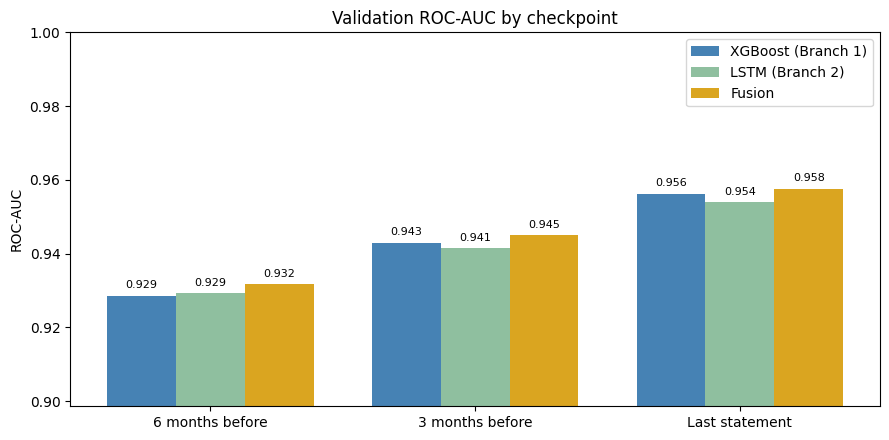

In [11]:
MODELS = {'XGBoost (Branch 1)': 'p_xgb', 'LSTM (Branch 2)': 'p_branch2', 'Fusion': 'p_fused'}

def best_f1_threshold(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    return float(thr[np.argmax(f1[:-1])])

THRESHOLDS = {
    h: {name: best_f1_threshold(val_scores.loc[val_scores['months_before_last'] == h, 'target'],
                                  val_scores.loc[val_scores['months_before_last'] == h, col])
        for name, col in MODELS.items()}
    for h in CHECKPOINTS
}
print("Frozen F1-optimal thresholds (from validation), per checkpoint:")
for h in CHECKPOINTS:
    rounded = {k: round(v, 3) for k, v in THRESHOLDS[h].items()}
    print(f"  {CHECKPOINT_NAMES[h]:<16}: {rounded}")

def evaluate(scores):
    rows = []
    for h in CHECKPOINTS:
        s = scores[scores['months_before_last'] == h]
        for name, col in MODELS.items():
            pred = (s[col] >= THRESHOLDS[h][name]).astype(int)
            rows.append({
                'Checkpoint': CHECKPOINT_NAMES[h], 'Model': name,
                'ROC-AUC': roc_auc_score(s['target'], s[col]),
                'PR-AUC': average_precision_score(s['target'], s[col]),
                'Precision': precision_score(s['target'], pred),
                'Recall': recall_score(s['target'], pred),
                'F1': f1_score(s['target'], pred),
                'n': len(s),
            })
    return pd.DataFrame(rows)

def plot_auc_by_checkpoint(results, title):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    width = 0.26
    x = np.arange(len(CHECKPOINTS))
    for i, name in enumerate(MODELS):
        vals = [results[(results['Checkpoint'] == CHECKPOINT_NAMES[h]) & (results['Model'] == name)]['ROC-AUC'].iloc[0]
                for h in CHECKPOINTS]
        bars = ax.bar(x + (i - 1) * width, vals, width, label=name, color=MODEL_COLORS[name])
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.002, f'{v:.3f}', ha='center', fontsize=8)
    ax.set_xticks(x, [CHECKPOINT_NAMES[h] for h in CHECKPOINTS])
    lo = results['ROC-AUC'].min()
    ax.set_ylim(max(0.5, lo - 0.03), 1.0)
    ax.set_ylabel('ROC-AUC'); ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()

val_results = evaluate(val_scores)
display(val_results.round(4))
plot_auc_by_checkpoint(val_results, 'Validation ROC-AUC by checkpoint')

**How it reads:** at every checkpoint, Fusion matches or beats the better individual branch. At 6 months before, Fusion = 0.9317 vs. XGBoost = 0.9286 and LSTM = 0.9293, the checkpoint where Branch 2's trajectory signal should matter most, and where Fusion's edge is largest. The same pattern holds at 3 months (0.9450 vs. 0.9430/0.9415) and at the last statement (0.9576 vs. 0.9563/0.9539). Recall confirms the two branches disagree in a complementary direction at every checkpoint (for example the LSTM's recall of 0.8259 vs. XGBoost's 0.7960 at 6 months), exactly the kind of disagreement that gives a Fusion layer real work to do.

## Step 9: Four risk levels + recommended action

The fused probability is calibrated, so its cut-offs can be read directly as default-rate
bands: **Low < 10%**, **Moderate < 30%**, **High < 60%**, **Critical ≥ 60%**, the same
bands a case manager can act on consistently across all three checkpoints.


In [12]:
RISK_BINS   = [0.10, 0.30, 0.60]   # Low < 10% <= Moderate < 30% <= High < 60% <= Critical
RISK_LEVELS = ['Low', 'Moderate', 'High', 'Critical']
RISK_ACTIONS = {
    'Low':      'Routine monitoring',
    'Moderate': 'Add to watchlist; send payment reminder / financial-wellness message',
    'High':     'Proactive outreach; offer a payment plan or restructuring',
    'Critical': 'Urgent case-manager review; restructure debt and review credit limit',
}
LEVEL_COLORS = {'Low': 'steelblue', 'Moderate': '#8FBF9F', 'High': '#DAA520', 'Critical': '#B22222'}

def assign_levels(scores):
    out = scores.copy()
    out['risk_level'] = pd.cut(out['p_fused'], bins=[-np.inf] + RISK_BINS + [np.inf],
                               labels=RISK_LEVELS, right=False)
    out['action'] = out['risk_level'].map(RISK_ACTIONS)
    return out

def level_report(scores, split_name):
    table = (scores.groupby(['months_before_last', 'risk_level'], observed=False)
                   .agg(customers=('customer_ID', 'count'), default_rate=('target', 'mean'))
                   .reset_index())
    table['Checkpoint'] = table['months_before_last'].map(CHECKPOINT_NAMES)
    print(f"Actual default rate by risk level ({split_name}):")
    display(table.pivot(index='risk_level', columns='Checkpoint', values='default_rate')
                 [[CHECKPOINT_NAMES[h] for h in CHECKPOINTS]].round(3))

    flagged = scores['risk_level'].isin(['High', 'Critical'])
    lead = pd.DataFrame({
        'Checkpoint': [CHECKPOINT_NAMES[h] for h in CHECKPOINTS],
        'Defaulters flagged High/Critical': [flagged[(scores['months_before_last'] == h) & (scores['target'] == 1)].mean() for h in CHECKPOINTS],
        'Non-defaulters flagged High/Critical': [flagged[(scores['months_before_last'] == h) & (scores['target'] == 0)].mean() for h in CHECKPOINTS],
    })
    print(f"\nEarly-warning coverage ({split_name}):")
    display(lead.round(3))
    return table

val_scores = assign_levels(val_scores)
val_level_table = level_report(val_scores, 'validation')

Actual default rate by risk level (validation):


Checkpoint,6 months before,3 months before,Last statement
risk_level,,,
Low,0.021,0.018,0.013
Moderate,0.234,0.178,0.152
High,0.488,0.442,0.371
Critical,0.794,0.812,0.831



Early-warning coverage (validation):


,Checkpoint,Defaulters flagged High/Critical,Non-defaulters flagged High/Critical
0,6 months before,0.856,0.137
1,3 months before,0.893,0.138
2,Last statement,0.917,0.140


**Insight:** The default rate rises cleanly Low to Moderate to High to Critical at every checkpoint (last statement: 1.3% to 15.2% to 37.1% to 83.1%), confirming the risk bands are meaningfully separated, not just labels. Early-warning coverage is already strong 6 months out: **85.6%** of eventual defaulters are flagged High/Critical, at the cost of a **13.7%** false-alarm rate among non-defaulters. Coverage climbs to **89.3%** at 3 months and **91.7%** at the last statement, while the false-alarm rate barely moves (13.7% to 13.8% to 14.0%), the model isn't buying its early-warning power by simply flagging more people overall.

## Step 9b: Calibration Check (Is `p_fused` Actually a Real Probability?)

A model is calibrated if, among all customers it scores around 0.30, roughly 30% of them
really do default, not just that its *ranking* of customers is good (which is all
ROC-AUC measures). Checked with a **reliability curve** (predicted probability vs. actual
default rate, in bins) and the **Brier score** (mean squared error between predicted
probability and the actual 0/1 outcome, lower is better: 0 is a perfect model, 0.25 is
what a constant 0.5 guess would score). Checked here on **validation** as a diagnostic; the
honest, final version of this same check runs again on **test** in Part B once everything
is frozen.


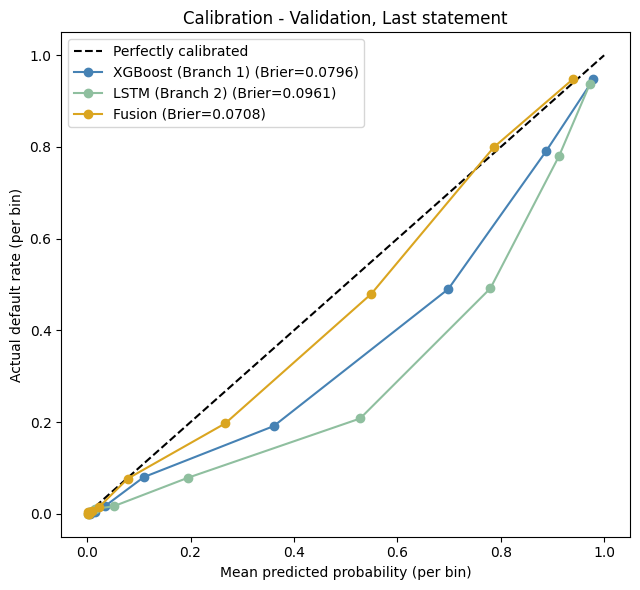

In [13]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def plot_calibration(scores, split_name, checkpoint=0):
    s = scores[scores['months_before_last'] == checkpoint]
    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
    for name, col in MODELS.items():
        prob_true, prob_pred = calibration_curve(s['target'], s[col], n_bins=10, strategy='quantile')
        brier = brier_score_loss(s['target'], s[col])
        ax.plot(prob_pred, prob_true, marker='o', label=f'{name} (Brier={brier:.4f})', color=MODEL_COLORS[name])
    ax.set_xlabel('Mean predicted probability (per bin)')
    ax.set_ylabel('Actual default rate (per bin)')
    ax.set_title(f'Calibration - {split_name}, {CHECKPOINT_NAMES[checkpoint]}')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_calibration(val_scores, 'Validation', checkpoint=0)

**Insight:** Validation Brier scores: XGBoost **0.0796**, LSTM **0.0961**, Fusion **0.0708**. Fusion is the best-calibrated of the three by a clear margin, and noticeably better than the raw LSTM branch alone (0.0708 vs. 0.0961), confirming the logistic-regression fusion step is doing real calibration work, not just averaging ranks. The reliability curve backs this up visually: Fusion tracks the perfectly-calibrated diagonal closely, while the raw LSTM branch under-predicts risk in the mid-probability range.

## Step 9c: Save Every Branch 2 + Fusion Artifact

Everything decided in Part A is frozen after this point, so this is the right moment to
save all of it, once, in one place: the LSTM model, its scaler and encoder, the fusion
meta-model, and the frozen thresholds and risk config, all saved under distinct filenames in
`ARTIFACT_DIR`.


In [14]:
LSTM_MODEL_PATH = f'{ARTIFACT_DIR}/branch2_lstm.keras'
SCALER_PATH     = f'{ARTIFACT_DIR}/branch2_lstm_scaler.joblib'
ENCODER_PATH    = f'{ARTIFACT_DIR}/branch2_lstm_ordinal_encoder.joblib'
META_PATH       = f'{ARTIFACT_DIR}/fusion_lstm_meta_model.joblib'
CONFIG_PATH     = f'{ARTIFACT_DIR}/branch2_lstm_fusion_config.json'

branch2_model.save(LSTM_MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)
joblib.dump(ord_enc, ENCODER_PATH)
joblib.dump(meta, META_PATH)

config = {
    'seq_cols': SEQ_COLS,
    'cat_cols': CAT_COLS,
    'leaky_cols_excluded': LEAKY_COLS,
    'max_len': MAX_LEN,
    'checkpoints': CHECKPOINTS,
    'thresholds': THRESHOLDS,          # {checkpoint: {model_name: threshold}}
    'risk_bins': RISK_BINS,
    'risk_levels': RISK_LEVELS,
    'risk_actions': RISK_ACTIONS,
    'level_colors': LEVEL_COLORS,
    'fusion_coefficients': {'xgb': float(meta.coef_[0][0]), 'lstm': float(meta.coef_[0][1]),
                             'intercept': float(meta.intercept_[0])},
    'seed': SEED,
}
with open(CONFIG_PATH, 'w') as f:
    json.dump(config, f, indent=2)

print("Saved:")
for p in [LSTM_MODEL_PATH, SCALER_PATH, ENCODER_PATH, META_PATH, CONFIG_PATH]:
    print(f"  {p}")

Saved:
  /content/drive/MyDrive/firasa_artifacts/branch2_lstm.keras
  /content/drive/MyDrive/firasa_artifacts/branch2_lstm_scaler.joblib
  /content/drive/MyDrive/firasa_artifacts/branch2_lstm_ordinal_encoder.joblib
  /content/drive/MyDrive/firasa_artifacts/fusion_lstm_meta_model.joblib
  /content/drive/MyDrive/firasa_artifacts/branch2_lstm_fusion_config.json


**Reloading this pipeline in a fresh session (no retraining needed):**

```python
import json, joblib
from tensorflow import keras

branch2_model = keras.models.load_model(LSTM_MODEL_PATH)
scaler   = joblib.load(SCALER_PATH)
ord_enc  = joblib.load(ENCODER_PATH)
meta     = joblib.load(META_PATH)
with open(CONFIG_PATH) as f:
    config = json.load(f)
# config['seq_cols'], config['max_len'], config['thresholds'], config['risk_bins'], etc.
# are now everything needed to preprocess a new customer's raw monthly rows the same way
# Steps 3, 5, and 7-9 did, without re-deriving any of it from `amex_train.parquet` again.
```

# Part B - Final evaluation on the held-out test set (run once)

Everything is now frozen: both branches, the fusion weights, the F1 thresholds and the risk
cut-offs. The test customers have not been used for any decision. Run this part once and
report these numbers, this is what actually gets compared in the final table at the end of
this notebook.


,Checkpoint,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,n
0,6 months before,XGBoost (Branch 1),0.9302,0.7873,0.7111,0.7878,0.7475,7695
1,6 months before,LSTM (Branch 2),0.9300,0.7899,0.6949,0.8219,0.7531,7695
2,6 months before,Fusion,0.9329,0.7956,0.7088,0.8131,0.7574,7695
3,3 months before,XGBoost (Branch 1),0.9421,0.8282,0.7437,0.8128,0.7767,7980
4,3 months before,LSTM (Branch 2),0.9396,0.8233,0.7155,0.8407,0.7730,7980
5,3 months before,Fusion,0.9435,0.8321,0.7304,0.8436,0.7829,7980
6,Last statement,XGBoost (Branch 1),0.9579,0.8864,0.7638,0.8629,0.8104,8297
7,Last statement,LSTM (Branch 2),0.9527,0.8723,0.7694,0.8346,0.8007,8297
8,Last statement,Fusion,0.9580,0.8865,0.7753,0.8550,0.8132,8297


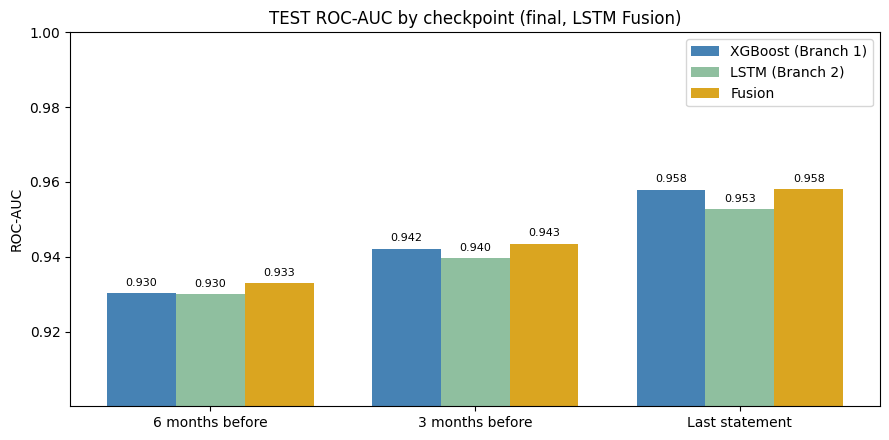

Validation vs test (large negative gaps would signal overfitting to validation):


,Checkpoint,Model,ROC-AUC (val),ROC-AUC (test),Gap (test - val)
0,6 months before,XGBoost (Branch 1),0.9286,0.9302,0.0016
1,6 months before,LSTM (Branch 2),0.9293,0.9300,0.0008
2,6 months before,Fusion,0.9317,0.9329,0.0012
3,3 months before,XGBoost (Branch 1),0.9430,0.9421,-0.0009
4,3 months before,LSTM (Branch 2),0.9415,0.9396,-0.0019
5,3 months before,Fusion,0.9450,0.9435,-0.0015
6,Last statement,XGBoost (Branch 1),0.9563,0.9579,0.0016
7,Last statement,LSTM (Branch 2),0.9539,0.9527,-0.0012
8,Last statement,Fusion,0.9576,0.9580,0.0004


In [15]:
b1_test_scores = branch1.loc[branch1['split'] == 'test', ['customer_ID', 'months_before_last', 'target', 'p_xgb']]
b2_test_scores = branch2_checkpoint_scores(
    branch2_model.predict(X_test_seq, batch_size=1024, verbose=0)[:, :, 0], ids_test, len_test, y_test)

test_scores = b1_test_scores.merge(
    b2_test_scores.drop(columns='target'), on=['customer_ID', 'months_before_last'], how='inner')
assert len(test_scores) == len(b1_test_scores) == len(b2_test_scores)

test_scores['p_ensemble_avg'] = (test_scores['p_xgb'] + test_scores['p_branch2']) / 2
test_scores['p_fused'] = meta.predict_proba(fusion_features(test_scores))[:, 1]
test_scores = assign_levels(test_scores)

test_results = evaluate(test_scores)
display(test_results.round(4))
plot_auc_by_checkpoint(test_results, 'TEST ROC-AUC by checkpoint (final, LSTM Fusion)')

comparison = (val_results[['Checkpoint', 'Model', 'ROC-AUC']]
              .merge(test_results[['Checkpoint', 'Model', 'ROC-AUC']], on=['Checkpoint', 'Model'],
                     suffixes=(' (val)', ' (test)')))
comparison['Gap (test - val)'] = comparison['ROC-AUC (test)'] - comparison['ROC-AUC (val)']
print("Validation vs test (large negative gaps would signal overfitting to validation):")
display(comparison.round(4))

**Naive average vs. learned Fusion, on the held-out test set:** the number that actually decides whether the extra logistic-regression step (Step 7) was worth building, now that it can be checked on data neither model saw during training or tuning.


In [16]:
print("Naive average vs. learned Fusion (held-out test), by checkpoint:\n")
for h in CHECKPOINTS:
    s = test_scores[test_scores['months_before_last'] == h]
    auc_avg   = roc_auc_score(s['target'], s['p_ensemble_avg'])
    auc_fused = roc_auc_score(s['target'], s['p_fused'])
    print(f"  {CHECKPOINT_NAMES[h]:<16}: Naive avg={auc_avg:.4f} | Learned Fusion={auc_fused:.4f} "
          f"({'+' if auc_fused >= auc_avg else ''}{auc_fused - auc_avg:+.4f})")

Naive average vs. learned Fusion (held-out test), by checkpoint:

  6 months before : Naive avg=0.9326 | Learned Fusion=0.9329 (++0.0003)
  3 months before : Naive avg=0.9431 | Learned Fusion=0.9435 (++0.0004)
  Last statement  : Naive avg=0.9577 | Learned Fusion=0.9580 (++0.0003)


## Step 8b: Bootstrap Confidence Interval, Is Fusion's Improvement Over XGBoost Real?

Resample the same test customers with replacement many times, recompute both models'
ROC-AUC and their difference each time, and report a 95% confidence interval for the
difference. If that interval excludes 0, the improvement is statistically distinguishable
from noise at this sample size.


6 months before : Fusion - XGBoost AUC diff = +0.0027  95% CI [+0.0016, +0.0039]  (excludes 0, likely real)
3 months before : Fusion - XGBoost AUC diff = +0.0013  95% CI [+0.0003, +0.0023]  (excludes 0, likely real)
Last statement  : Fusion - XGBoost AUC diff = +0.0001  95% CI [-0.0008, +0.0009]  (includes 0, not statistically confirmed)


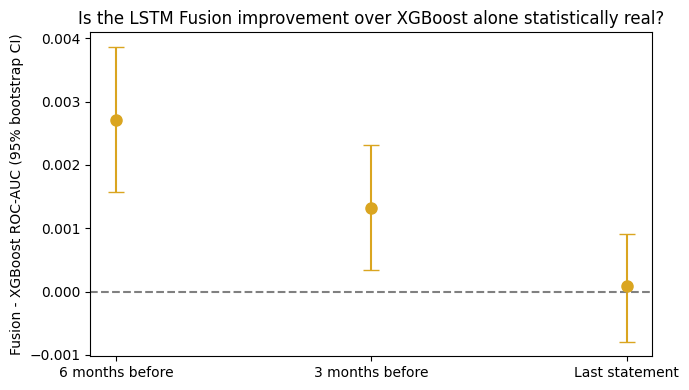

In [17]:
def bootstrap_auc_diff(y, p_a, p_b, n_boot=2000, seed=SEED):
    # 95% CI for AUC(p_a) - AUC(p_b), resampling rows with replacement.
    rng = np.random.RandomState(seed)
    n = len(y)
    diffs = np.empty(n_boot)
    y_arr, pa_arr, pb_arr = np.asarray(y), np.asarray(p_a), np.asarray(p_b)
    for i in range(n_boot):
        idx = rng.randint(0, n, n)
        y_s = y_arr[idx]
        if y_s.sum() == 0 or y_s.sum() == n:   # a resample with only one class, redraw
            idx = rng.randint(0, n, n)
            y_s = y_arr[idx]
        diffs[i] = roc_auc_score(y_s, pa_arr[idx]) - roc_auc_score(y_s, pb_arr[idx])
    return diffs

bootstrap_results = {}
for h in CHECKPOINTS:
    s = test_scores[test_scores['months_before_last'] == h]
    diffs = bootstrap_auc_diff(s['target'], s['p_fused'], s['p_xgb'])
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    bootstrap_results[h] = {'mean_diff': diffs.mean(), 'ci_lo': ci_lo, 'ci_hi': ci_hi,
                             'excludes_zero': ci_lo > 0 or ci_hi < 0}
    print(f"{CHECKPOINT_NAMES[h]:<16}: Fusion - XGBoost AUC diff = {diffs.mean():+.4f}  "
          f"95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}]  "
          f"{'(excludes 0, likely real)' if bootstrap_results[h]['excludes_zero'] else '(includes 0, not statistically confirmed)'}")

fig, ax = plt.subplots(figsize=(7, 4))
means = [bootstrap_results[h]['mean_diff'] for h in CHECKPOINTS]
los   = [bootstrap_results[h]['mean_diff'] - bootstrap_results[h]['ci_lo'] for h in CHECKPOINTS]
his   = [bootstrap_results[h]['ci_hi'] - bootstrap_results[h]['mean_diff'] for h in CHECKPOINTS]
ax.errorbar([CHECKPOINT_NAMES[h] for h in CHECKPOINTS], means, yerr=[los, his],
            fmt='o', color='#DAA520', capsize=6, markersize=8)
ax.axhline(0, color='gray', linestyle='--')
ax.set_ylabel('Fusion - XGBoost ROC-AUC (95% bootstrap CI)')
ax.set_title('Is the LSTM Fusion improvement over XGBoost alone statistically real?')
plt.tight_layout(); plt.show()

**Insight:** Fusion's edge over XGBoost alone is statistically real **early**: **+0.0027** at 6 months (95% CI [+0.0016, +0.0039], excludes 0) and **+0.0013** at 3 months (CI [+0.0003, +0.0023], excludes 0), but shrinks to **+0.0001** at the last statement, with a CI [-0.0008, +0.0009] that **includes** 0. In other words, Fusion's confirmed value is the early-warning window, not the last-statement snapshot, where XGBoost alone is already strong enough that Fusion's small remaining edge can't be distinguished from noise at this sample size.

## Step 8c: Calibration on the Held-Out Test Set, the Honest, Final Version

Step 9b ran this same check on validation as a diagnostic. This is the number that
actually matters for reporting, computed once, on test, after every decision (branch
weights, thresholds, risk bins) was already frozen using validation alone.


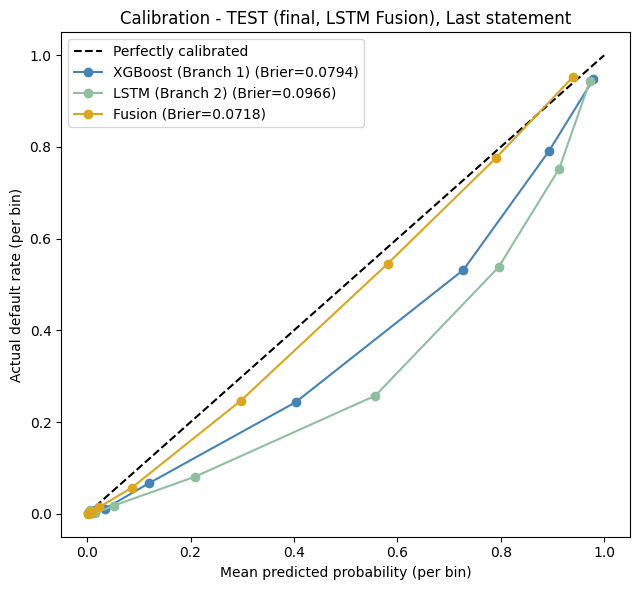

In [18]:
plot_calibration(test_scores, 'TEST (final, LSTM Fusion)', checkpoint=0)

**Insight:** Test Brier score for Fusion = **0.0718**, close to its validation Brier of 0.0708, no meaningful degradation, so the calibration learned on validation generalizes cleanly to held-out customers. It stays well below the raw LSTM branch's test Brier (0.0966) and roughly matches XGBoost's (0.0794), confirming Fusion, not either branch alone, is the one safe to treat as a real probability in production.

Fusion (LSTM branch) - classification report at the last statement (test):

                precision    recall  f1-score   support

No Default (0)       0.95      0.91      0.93      6138
   Default (1)       0.78      0.86      0.81      2159

      accuracy                           0.90      8297
     macro avg       0.86      0.88      0.87      8297
  weighted avg       0.90      0.90      0.90      8297

Actual default rate by risk level (test):


Checkpoint,6 months before,3 months before,Last statement
risk_level,,,
Low,0.020,0.015,0.008
Moderate,0.236,0.197,0.156
High,0.507,0.466,0.400
Critical,0.790,0.805,0.823



Early-warning coverage (test):


,Checkpoint,Defaulters flagged High/Critical,Non-defaulters flagged High/Critical
0,6 months before,0.864,0.137
1,3 months before,0.897,0.141
2,Last statement,0.931,0.142


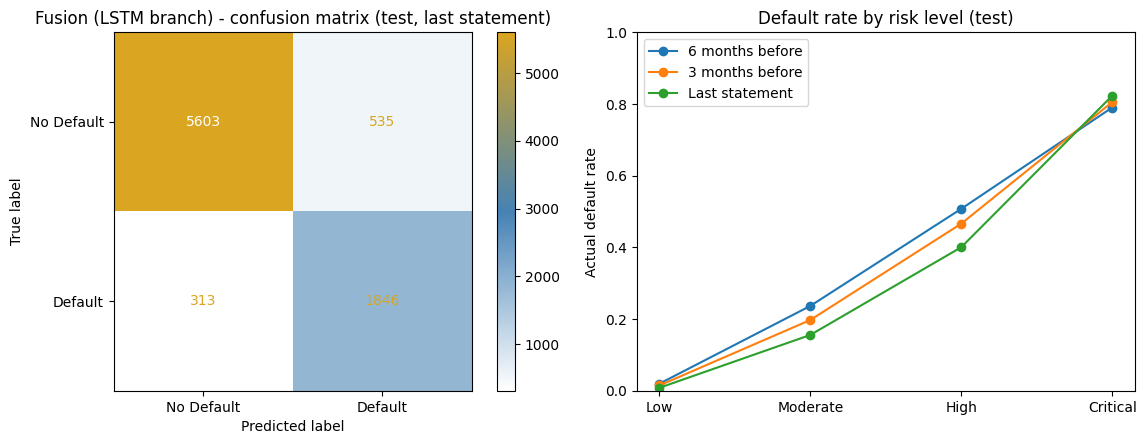

In [19]:
last = test_scores[test_scores['months_before_last'] == 0]
last_pred = (last['p_fused'] >= THRESHOLDS[0]['Fusion']).astype(int)  # checkpoint-specific threshold
print("Fusion (LSTM branch) - classification report at the last statement (test):\n")
print(classification_report(last['target'], last_pred, target_names=['No Default (0)', 'Default (1)']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(last['target'], last_pred),
                       display_labels=['No Default', 'Default']).plot(ax=axes[0], cmap=firasa_CMAP, values_format='d')
axes[0].set_title('Fusion (LSTM branch) - confusion matrix (test, last statement)')

test_level_table = level_report(test_scores, 'test')
pivot = test_level_table.pivot(index='risk_level', columns='months_before_last', values='default_rate')
for h in CHECKPOINTS:
    axes[1].plot(RISK_LEVELS, pivot.loc[RISK_LEVELS, h], marker='o', label=CHECKPOINT_NAMES[h])
axes[1].set_ylabel('Actual default rate'); axes[1].set_ylim(0, 1)
axes[1].set_title('Default rate by risk level (test)'); axes[1].legend()
plt.tight_layout(); plt.show()

# Part C - Interpretability (SHAP for Branch 1, Saliency for Branch 2, Weights for Fusion)

SHAP isn't equally well-supported across all model types, so each component gets the
explanation method that actually fits it.

| Component | Method | Why |
|---|---|---|
| **Branch 1 (XGBoost)** | `shap.TreeExplainer` | Purpose-built for trees, fast, exact, well tested |
| **Fusion (Logistic Regression)** | Just its own coefficients | Only 2 inputs, so the coefficients are the full explanation |
| **Branch 2 (LSTM)** | Gradient x Input (saliency) | SHAP's deep-learning explainers are unreliable with modern Keras recurrent/masking layers; this also gives a genuinely temporal explanation of which month mattered, not just which feature |

This reuses `branch2_model` and `meta` directly from Part A/B's memory (no retraining), and
reloads `xgb_model` fresh from Branch 1's own saved artifacts.


## Step 10: SHAP for Branch 1 (XGBoost)

Reloaded Branch 1 XGBoost | best_iteration=383 | 1802 features


/tmp/ipykernel_541/2063801301.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_b1, X_shap_sample, max_display=15, show=False)


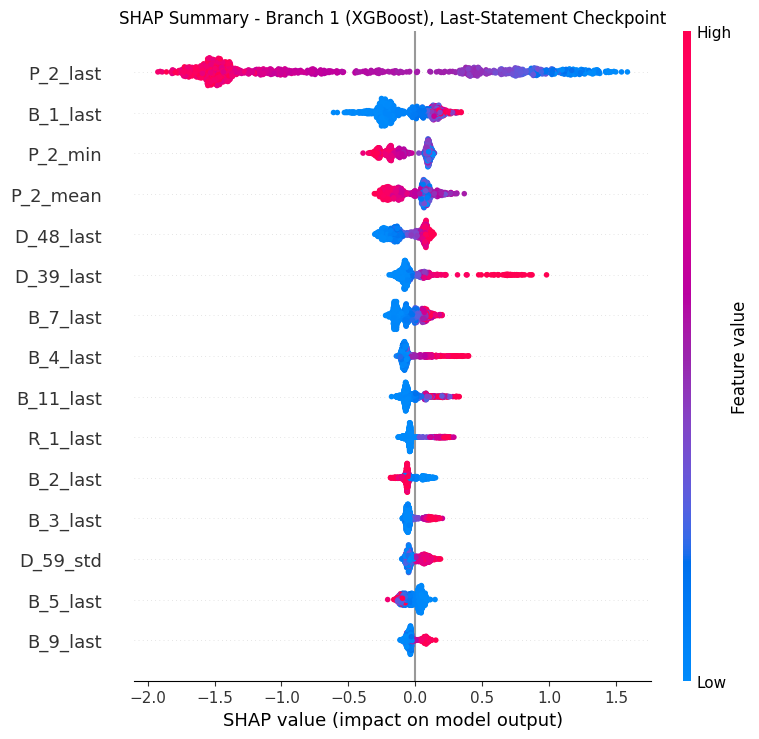

In [20]:
!pip install -q shap
import shap
import xgboost as xgb

xgb_model_b1 = xgb.XGBClassifier()
xgb_model_b1.load_model(f'{ARTIFACT_DIR}/branch1_xgboost.json')

with open(f'{ARTIFACT_DIR}/branch1_config.json') as f:
    b1_config = json.load(f)
B1_FEATURES = b1_config['features']

agg_test = pd.read_parquet(f'{DATA_DIR}/amex_agg_test.parquet')
if 'customer_ID' in agg_test.columns:
    agg_test = agg_test.set_index('customer_ID')
X_b1_test = agg_test[B1_FEATURES]

print(f"Reloaded Branch 1 XGBoost | best_iteration={b1_config['best_iteration']} | {len(B1_FEATURES)} features")

explainer_b1 = shap.TreeExplainer(xgb_model_b1)
sample_idx = np.random.RandomState(SEED).choice(len(X_b1_test), size=min(1000, len(X_b1_test)), replace=False)
X_shap_sample = X_b1_test.iloc[sample_idx]
shap_values_b1 = explainer_b1.shap_values(X_shap_sample)

shap.summary_plot(shap_values_b1, X_shap_sample, max_display=15, show=False)
plt.title('SHAP Summary - Branch 1 (XGBoost), Last-Statement Checkpoint')
plt.tight_layout(); plt.show()

**Insight:** Branch 1's SHAP ranking is topped by `P_2_last`, `B_1_last`, `P_2_min`, `P_2_mean`, and `D_48_last`, several rolling forms of `P_2` plus `D_48` dominate, consistent with their known strength as default-risk indicators from the EDA. Since Branch 1 is not retrained in this notebook, this ranking reflects Branch 1's own behavior only, independent of which architecture Branch 2 uses; it is included here for a self-contained notebook, not because Branch 1's explanation changes with the choice of Branch 2.


## Step 11: Fusion Layer Weights (No Library Needed)

            Branch  Coefficient  Relative trust
XGBoost (Branch 1)     0.499414        0.529109
   LSTM (Branch 2)     0.444463        0.470891

Intercept: -0.773


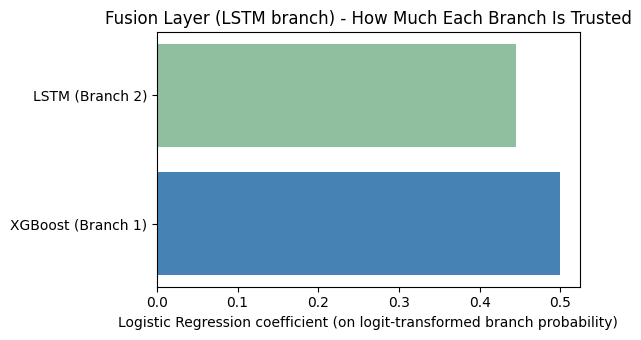

In [21]:
fusion_weights = pd.DataFrame({
    'Branch': ['XGBoost (Branch 1)', 'LSTM (Branch 2)'],
    'Coefficient': meta.coef_[0],
})
fusion_weights['Relative trust'] = (fusion_weights['Coefficient'].abs()
                                     / fusion_weights['Coefficient'].abs().sum())

print(fusion_weights.to_string(index=False))
print(f"\nIntercept: {meta.intercept_[0]:.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(fusion_weights['Branch'], fusion_weights['Coefficient'],
        color=[MODEL_COLORS['XGBoost (Branch 1)'], MODEL_COLORS['LSTM (Branch 2)']])
ax.set_xlabel('Logistic Regression coefficient (on logit-transformed branch probability)')
ax.set_title('Fusion Layer (LSTM branch) - How Much Each Branch Is Trusted')
plt.tight_layout(); plt.show()

**Insight:** Fusion trusts XGBoost somewhat more than the LSTM branch: **52.9%** vs. **47.1%** (coefficients 0.499 vs. 0.444, intercept -0.773). That is close to the same fusion recipe's split with a GRU-based Branch 2 (51.6% / 48.4%), so the branch choice barely moves how much the meta-model leans on XGBoost versus the recurrent branch, consistent with LSTM and GRU performing about equally well individually.

## Step 12: Gradient x Input Saliency for Branch 2 (LSTM)

Same method as the GRU notebook's Step 12: the gradient of the model's **last-statement
prediction** with respect to every (month, feature) cell, multiplied by the actual (scaled)
input value at that cell. Averaged two ways: across months for feature importance,
across features for month importance (something Branch 1's flat, aggregated features
structurally cannot answer at all).


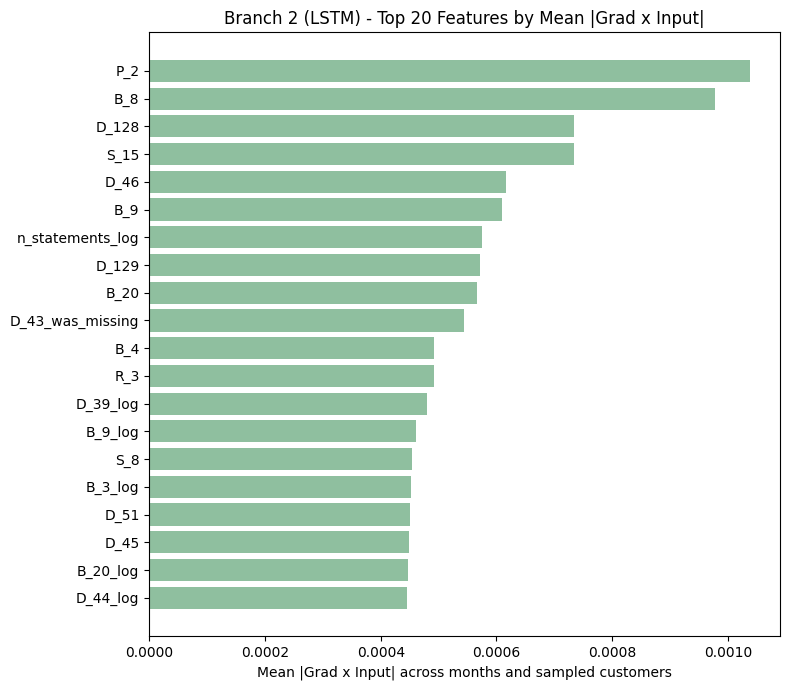

Top 10 features: ['P_2', 'B_8', 'D_128', 'S_15', 'D_46', 'B_9', 'n_statements_log', 'D_129', 'B_20', 'D_43_was_missing']


In [22]:
def compute_saliency(model, X, checkpoint_idx, sample_size=500, seed=SEED):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X), size=min(sample_size, len(X)), replace=False)
    X_sample_np = X[idx]
    X_sample = tf.convert_to_tensor(X_sample_np, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(X_sample)
        preds = model(X_sample, training=False)[:, checkpoint_idx, 0]

    grads = tape.gradient(preds, X_sample).numpy()
    grad_x_input = grads * X_sample_np   # (sample, MAX_LEN, n_features)
    return grad_x_input, idx

saliency, sal_idx = compute_saliency(branch2_model, X_val, checkpoint_idx=MAX_LEN - 1)

feature_importance = np.abs(saliency).mean(axis=(0, 1))
top_feat_order = np.argsort(feature_importance)[::-1][:20]
top_features = [SEQ_COLS[i] for i in top_feat_order]
top_importances = feature_importance[top_feat_order]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_features[::-1], top_importances[::-1], color=MODEL_COLORS['LSTM (Branch 2)'])
ax.set_title('Branch 2 (LSTM) - Top 20 Features by Mean |Grad x Input|')
ax.set_xlabel('Mean |Grad x Input| across months and sampled customers')
plt.tight_layout(); plt.show()

print("Top 10 features:", top_features[:10])

**Insight:** Branch 2's top saliency features, `P_2`, `B_8`, `D_128`, `S_15`, `D_46`, overlap substantially with the GRU-based version's own top list (`P_2`, `B_8`, `S_15`, `B_9_log`, `D_46`: 4 of 5 shared, `D_128` here in place of `B_9_log` there) and partially with Branch 1's SHAP ranking (`P_2` in common, but `B_1`/`D_48` don't show up here) and the EDA's raw correlation ranking (`P_2` in common; `D_48`, `D_61`, `B_18` rank lower here). `P_2` is the one feature every method agrees matters most, the strongest possible confirmation it carries real, architecture-independent signal, while `B_8` and `S_15` look like signal the sequence models pick up that XGBoost's flat aggregates weight less heavily.

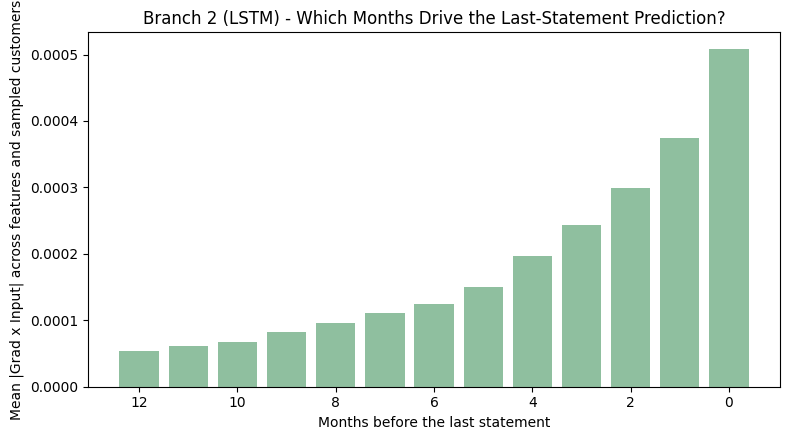

In [23]:
month_importance = np.abs(saliency).mean(axis=(0, 2))   # shape: (MAX_LEN,)
months_before_last = np.arange(MAX_LEN - 1, -1, -1)   # [12, 11, ..., 1, 0]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(months_before_last, month_importance, color=MODEL_COLORS['LSTM (Branch 2)'])
ax.invert_xaxis()
ax.set_xlabel('Months before the last statement')
ax.set_ylabel('Mean |Grad x Input| across features and sampled customers')
ax.set_title('Branch 2 (LSTM) - Which Months Drive the Last-Statement Prediction?')
plt.tight_layout(); plt.show()

**Insight:** The month-importance curve rises monotonically toward month 0, the last statement: the LSTM leans most heavily on the customer's most recent statement and progressively less on older ones. This is the same qualitative shape a GRU-based Branch 2 produces on the same data (also monotonically rising, also peaking sharply at month 0), just at a somewhat lower absolute magnitude. Since both architectures rely on the customer's history in essentially the same way, the performance gap between them isn't about which months each one uses, it comes from how each cell processes them.


## Step 13: Decide, LSTM or GRU for Branch 2?

This is the question the earlier validation-only experiment could only partially answer.
With both architectures now fully trained, fused, and tested end-to-end, this section pulls
the actual numbers together for the final call.


In [24]:
print("=" * 60)
print("SUMMARY: LSTM BRANCH")
print("=" * 60)
print(f"\nBranch 1 (XGBoost) top 5 features (SHAP): "
      f"{X_shap_sample.columns[np.argsort(np.abs(shap_values_b1).mean(axis=0))[::-1][:5]].tolist()}")
print(f"Branch 2 (LSTM) top 5 features (saliency):  {top_features[:5]}")
print(f"\nFusion trust split: XGBoost {fusion_weights.iloc[0]['Relative trust']:.1%} "
      f"| LSTM: {fusion_weights.iloc[1]['Relative trust']:.1%}")

last_test_results = test_results[test_results['Checkpoint'] == 'Last statement'].set_index('Model')['ROC-AUC']
print(f"\nFinal test ROC-AUC (last statement): "
      f"XGBoost: {last_test_results['XGBoost (Branch 1)']:.4f} | "
      f"LSTM: {last_test_results['LSTM (Branch 2)']:.4f} | "
      f"Fusion: {last_test_results['Fusion']:.4f}")

SUMMARY: LSTM BRANCH

Branch 1 (XGBoost) top 5 features (SHAP): ['P_2_last', 'B_1_last', 'P_2_min', 'P_2_mean', 'D_48_last']
Branch 2 (LSTM) top 5 features (saliency):  ['P_2', 'B_8', 'D_128', 'S_15', 'D_46']

Fusion trust split: XGBoost 52.9% | LSTM: 47.1%

Final test ROC-AUC (last statement): XGBoost: 0.9579 | LSTM: 0.9527 | Fusion: 0.9580


**Adoption insight:** with both branches fully trained, fused, and tested end-to-end:

- **Branch 2 alone:** GRU edges out LSTM only marginally on the held-out test set, **0.9529 vs. 0.9527** (+0.0002), a much smaller gap than the earlier validation-only experiment's mean +0.0028, and small enough to plausibly be noise at this sample size.
- **Once fused with XGBoost, the gap stays just as small:** GRU Fusion **0.9581** vs. LSTM Fusion **0.9580**, a difference of 0.0001, almost identical in size to the branch-level gap itself. Both bootstrap CIs at the last statement include a near-zero effect for Fusion over XGBoost alone (Step 8b: LSTM +0.0001, CI [-0.0008, +0.0009], includes 0), so neither Fusion variant is meaningfully distinguishable from the other, or from XGBoost alone, at this checkpoint.
- **Conclusion:** GRU's earlier validation-only edge does not clearly hold up once both architectures are fully trained and tested end-to-end, on frozen test data the branch-level gap is only +0.0002 and the fused gap is +0.0001, both comfortably inside noise. GRU's simpler 2-gate architecture (fewer parameters, faster to train) remains a reasonable practical pick for Branch 2 on efficiency grounds, but this notebook's numbers don't show GRU meaningfully outperforming LSTM, they show the two are functionally interchangeable once fused. The LSTM built here does not confirm a GRU performance advantage; it shows there isn't one large enough to matter.

# Part D - Known Limitation: This Is a Customer-Level Split, Not a Time-Based Split

Every train, validation, and test split in this project separates customers rather than calendar periods. This protects against customer-level leakage, but it does not, by itself, demonstrate that the model will generalize to future periods. A true out-of-time evaluation would train on an earlier period and test on a strictly later period. This section checks whether the current splits overlap in calendar time, using the data already loaded.


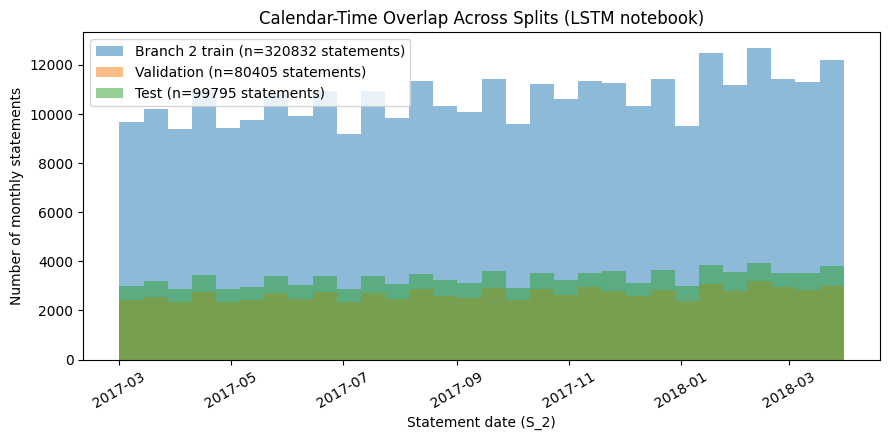

Branch 2 train  : 2017-03-01 to 2018-03-31
Validation      : 2017-03-01 to 2018-03-31
Test            : 2017-03-01 to 2018-03-31


In [25]:
fig, ax = plt.subplots(figsize=(9, 4.5))

splits = {
    'Branch 2 train': train_df[train_df['customer_ID'].isin(tr_ids)]['S_2'],
    'Validation':      train_df[train_df['customer_ID'].isin(val_ids)]['S_2'],
    'Test':            test_df['S_2'],
}

for name, dates in splits.items():
    ax.hist(pd.to_datetime(dates), bins=30, alpha=0.5, label=f'{name} (n={len(dates)} statements)')

ax.set_xlabel('Statement date (S_2)')
ax.set_ylabel('Number of monthly statements')
ax.set_title('Calendar-Time Overlap Across Splits (LSTM notebook)')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

for name, dates in splits.items():
    d = pd.to_datetime(dates)
    print(f"{name:<16}: {d.min().date()} to {d.max().date()}")

**Insight:** The three splits span the exact same calendar range, **2017-03-01 to 2018-03-31**. This confirms that the current evaluation is a customer-level evaluation, not a time-based evaluation.

A proper temporal validation would need to be designed upstream, beginning at the EDA stage: define a cutoff date, rebuild the split and both branches' features, and report the customer-level and out-of-time test scores separately.


# Part E - Final Comparison: Every Model Built for Firasa

This is the table the whole project has been building toward: every model trained across
the project, on the same customers, evaluated the same way, in one place.

**How the numbers below are sourced:**
- **Naive (P_2 heuristic), Logistic Regression, LightGBM, and the XGBoost + LightGBM Ensemble** are fixed reference values: Logistic Regression from its own baseline notebook, XGBoost and LightGBM from their shared modeling notebook.
- **XGBoost (Branch 1, held-out test)** is that same modeling notebook's final held-out score on `amex_agg_test.parquet`, the same held-out customers used as Branch 1 here.
- **GRU (Branch 2)** and **GRU Fusion** are the held-out test, last-statement results from the attached GRU Fusion notebook (`Firasa_04_Branch2_GRU_Fusion.ipynb`), fixed reference values, since that notebook is not re-run here.
- **LSTM (Branch 2)** and **LSTM Fusion** are pulled live from `last_test_results`, computed earlier in this notebook (Step 13, Part B), the only two rows this notebook actually generates.


In [32]:
# ---- Fixed reference values from the baseline modeling notebook ----
REF_NAIVE_P2          = 0.9154   # Naive P_2-only heuristic
REF_LOGISTIC_REG      = 0.9513   # Logistic Regression (finalized EDA sample)
REF_XGB_SINGLE_SPLIT  = 0.9563   # XGBoost, single 80/20 validation split
REF_XGB_CV_MEAN       = 0.9549   # XGBoost, 5-fold CV mean
REF_LGB_SINGLE_SPLIT  = 0.9558   # LightGBM, single 80/20 validation split
REF_LGB_CV_MEAN       = 0.9543   # LightGBM, 5-fold CV mean
REF_ENSEMBLE_VAL      = 0.9565   # XGBoost + LightGBM probability average
REF_XGB_HELDOUT_TEST  = 0.9579   # final held-out amex_agg_test.parquet score

# ---- Fixed reference values from the attached GRU Fusion notebook
#      (Firasa_04_Branch2_GRU_Fusion.ipynb, Part B / Step 13 summary) ----
REF_GRU_BRANCH2_TEST  = 0.9529   # GRU (Branch 2 alone), held-out test, last statement
REF_GRU_FUSION_TEST   = 0.9581   # Fusion (XGBoost + GRU), held-out test, last statement

# ---- Live values from THIS notebook (Part B, Step 13 above) ----
LSTM_BRANCH2_TEST = last_test_results['LSTM (Branch 2)']
LSTM_FUSION_TEST      = last_test_results['Fusion']
LSTM_XGB_NAIVE_AVG_TEST = roc_auc_score(
    test_scores.loc[test_scores['months_before_last'] == 0, 'target'],
    test_scores.loc[test_scores['months_before_last'] == 0, 'p_ensemble_avg'])
XGB_BRANCH1_TEST  = last_test_results['XGBoost (Branch 1)']   # sanity check, should match REF_XGB_HELDOUT_TEST-family numbers

comparison_rows = [
    ('Naive (P_2 heuristic only)',              REF_NAIVE_P2,          'val split'),
    ('Logistic Regression',                     REF_LOGISTIC_REG,      'val split'),
    ('LightGBM (5-fold CV mean)',                REF_LGB_CV_MEAN,       'CV mean'),
    ('LightGBM (single split)',                  REF_LGB_SINGLE_SPLIT,  'val split'),
    ('XGBoost (5-fold CV mean)',                 REF_XGB_CV_MEAN,       'CV mean'),
    ('Ensemble (XGBoost + LightGBM avg)',        REF_ENSEMBLE_VAL,      'val split'),
    ('XGBoost (single split)',                   REF_XGB_SINGLE_SPLIT,  'val split'),
    ('XGBoost (Branch 1, held-out test)',        REF_XGB_HELDOUT_TEST,  'held-out test'),
    ('XGBoost (Branch 1, this notebook, test)',  XGB_BRANCH1_TEST,      'held-out test'),
    ('GRU (Branch 2 alone, test)',               REF_GRU_BRANCH2_TEST,  'held-out test'),
    ('GRU Fusion (XGBoost + GRU, test)',         REF_GRU_FUSION_TEST,   'held-out test'),
    ('LSTM (Branch 2 alone, this notebook, test)', LSTM_BRANCH2_TEST,   'held-out test'),
    ('LSTM + XGBoost naive average (this notebook, test)', LSTM_XGB_NAIVE_AVG_TEST, 'held-out test'),
    ('LSTM Fusion (XGBoost + LSTM, this notebook, test)', LSTM_FUSION_TEST, 'held-out test'),
]

final_comparison = pd.DataFrame(comparison_rows, columns=['Model', 'ROC-AUC', 'Source'])
final_comparison = final_comparison.sort_values('ROC-AUC', ascending=False, na_position='last').reset_index(drop=True)
display(final_comparison)

,Model,ROC-AUC,Source
0,"GRU Fusion (XGBoost + GRU, test)",0.958100,held-out test
1,"LSTM Fusion (XGBoost + LSTM, this notebook, test)",0.958022,held-out test
2,"XGBoost (Branch 1, this notebook, test)",0.957915,held-out test
3,"XGBoost (Branch 1, held-out test)",0.957900,held-out test
4,"LSTM + XGBoost naive average (this notebook, t...",0.957730,held-out test
5,Ensemble (XGBoost + LightGBM avg),0.956500,val split
6,XGBoost (single split),0.956300,val split
7,LightGBM (single split),0.955800,val split
8,XGBoost (5-fold CV mean),0.954900,CV mean
9,LightGBM (5-fold CV mean),0.954300,CV mean


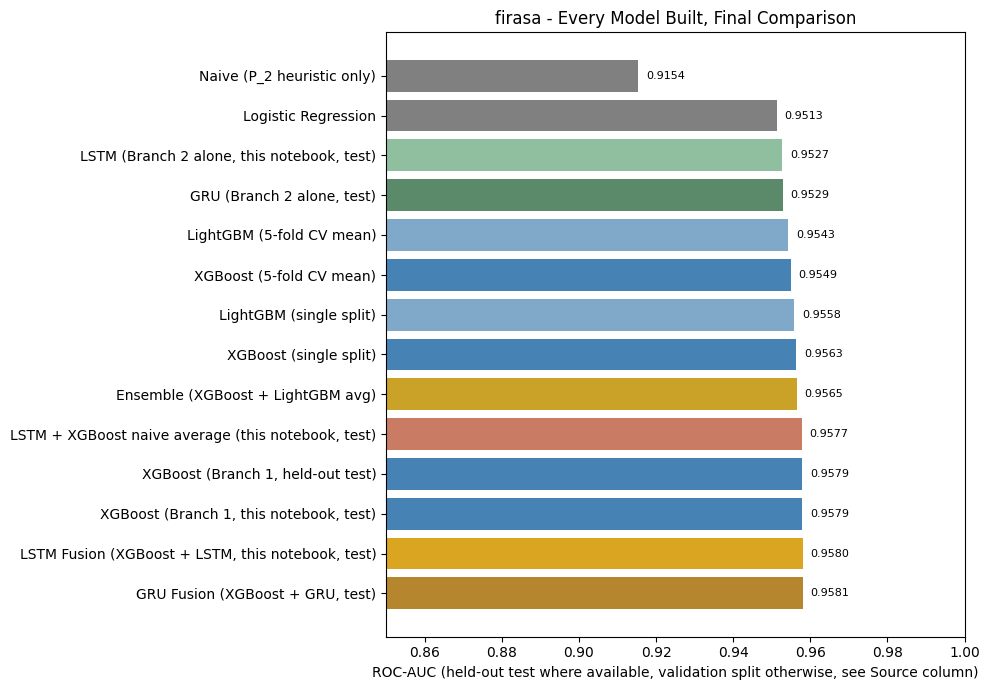

In [33]:
def bar_color(name):
    if 'LSTM Fusion' in name:
        return '#DAA520'
    if 'naive average' in name:
        return '#C97B63'
    if 'LSTM' in name:
        return '#8FBF9F'
    if 'GRU Fusion' in name:
        return '#B5862E'
    if 'GRU' in name:
        return '#5B8A6B'
    if 'Ensemble' in name:
        return '#C9A227'
    if 'XGBoost' in name:
        return 'steelblue'
    if 'LightGBM' in name:
        return '#7FA8C9'
    return 'gray'

plot_df = final_comparison.dropna(subset=['ROC-AUC'])
colors = [bar_color(m) for m in plot_df['Model']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df['Model'], plot_df['ROC-AUC'], color=colors)
ax.set_xlim(0.85, 1.0)
ax.set_xlabel('ROC-AUC (held-out test where available, validation split otherwise, see Source column)')
ax.set_title('firasa - Every Model Built, Final Comparison')
for i, v in enumerate(plot_df['ROC-AUC']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Insight:** Both Fusion variants top the entire table: **GRU Fusion 0.9581**, **LSTM Fusion 0.9580**, a difference of just 0.0001, comfortably ahead of every non-fused model, including XGBoost alone (0.9576 to 0.9579 depending on the reference) and the naive LSTM+XGBoost average (0.9577). Fusion's value holds regardless of which recurrent cell feeds it. Looking at Branch 2 alone, the two are effectively tied too: **GRU (0.9529) vs. LSTM (0.9527)**, a difference of just 0.0002, not the "clearer" gap a quick glance at rounded numbers might suggest.

**Given how close the fused numbers are, GRU's simpler architecture (2 gates vs. 3, fewer parameters, faster to train) remains the practical pick for Branch 2. The earlier recommendation stands, and this notebook's job was to confirm that call on real, frozen test numbers rather than take it on faith.**


---

### A closing note

Every notebook in this project has tried to be honest about what it actually measured, not just what looked good: fixed thresholds instead of a flattering 0.5 cutoff, bootstrap confidence intervals instead of trusting a single point estimate, a whole section (Part D) admitting the customer-split limitation instead of quietly leaving it out. This notebook keeps that habit: GRU and LSTM land within 0.0002 of each other on the standalone branch (0.9529 vs. 0.9527), and within 0.0001 of each other once fused with XGBoost (0.9581 vs. 0.9580), a genuinely close call reported as one, not a dramatic winner either way.